In [7]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from keras.models import Sequential
from keras.layers import Dense, SimpleRNN
from keras.optimizers import RMSprop
from keras.callbacks import Callback
from sklearn.metrics import mean_absolute_error, mean_squared_error
from scipy.stats import zscore

## Loading the Dataset and Visualizing the Humidity Time Series

In this section, we load the training and test datasets from  
`DailyDelhiClimateTrain.csv` and `DailyDelhiClimateTest.csv`.

We extract the **humidity** column as the target variable for our RNN model.  
A time-series plot is generated to inspect trend, seasonal behavior,
and potential noise in the data.


In [9]:
# Load training data
train_df = pd.read_csv("Datasets/DailyDelhiClimateTrain.csv")
train_df['date'] = pd.to_datetime(train_df['date'])
train_df.set_index('date', inplace=True)

In [ ]:
# Detect and handle outliers in 'humidity' column using Z-score method
z_scores = np.abs(zscore(train_df['humidity']))
outliers = z_scores > 3
print("Number of outliers:", outliers.sum())
train_df['humidity'] = train_df['humidity'].mask(outliers)
train_df['humidity'] = train_df['humidity'].interpolate(method='time')

Number of outliers: 0


In [3]:
# Load test data
test_df = pd.read_csv("Datasets/DailyDelhiClimateTest.csv")
test_df['date'] = pd.to_datetime(test_df['date'])
test_df.set_index('date', inplace=True)

In [115]:
# Extract humidity values
train = train_df['humidity'].values.reshape(-1,1)
test  = test_df['humidity'].values.reshape(-1,1)
print("Train shape:", train.shape)
print("Test shape :", test.shape)

Train shape: (1462, 1)
Test shape : (114, 1)


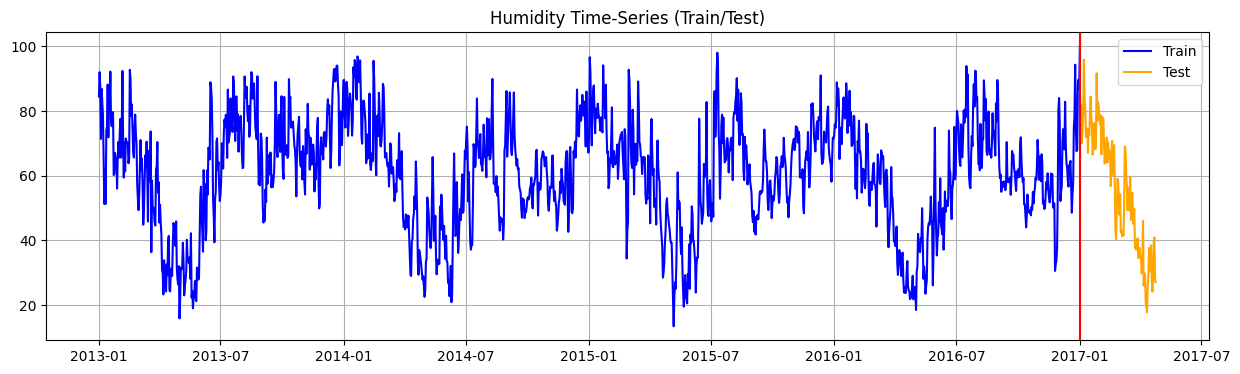

In [116]:
# Plot humidity time series
plt.figure(figsize=(15,4))
plt.plot(train_df.index, train, c='blue')
plt.plot(test_df.index,  test,  c='orange')
plt.axvline(test_df.index[0], c="red")
plt.legend(["Train", "Test"])
plt.title("Humidity Time-Series (Train/Test)")
plt.grid(True)
plt.show()

## Preparing Data for the RNN (Embedding / Step Size)

RNN models require sequences as input.  
We chose a window size (`step = 4`) and 7-days ahead horizon (`horizon = 7`), meaning the model will take **4 previous values**
to predict the next 7 values (weekly prediction).

To generate sliding windows, we create an extended version of each dataset
and convert them into supervised (X, Y) matrices.


In [86]:
# Define parameters for data preparation
step = 4        
horizon = 7

In [118]:
# Convert to supervised learning format for 7-day horizon
def convertToMatrix_multistep(data, step, horizon):
    X, Y = [], []
    for i in range(len(data) - step - horizon + 1):
        X.append(data[i:i+step])
        Y.append(data[i+step:i+step+horizon])
    return np.array(X), np.array(Y)


trainX, trainY = convertToMatrix_multistep(train, step, horizon)
trainX = trainX.reshape(trainX.shape[0], 1, trainX.shape[1])
trainY = trainY.reshape(trainY.shape[0], horizon)

print(f"Training shapes: X={trainX.shape}, Y={trainY.shape}")


testX, testY = convertToMatrix_multistep(test, step, horizon)
testX = testX.reshape(testX.shape[0], 1, testX.shape[1])
testY = testY.reshape(testY.shape[0], horizon)

print(f"Test shapes: X={testX.shape}, Y={testY.shape}")

Training shapes: X=(1452, 1, 4), Y=(1452, 7)
Test shapes: X=(104, 1, 4), Y=(104, 7)


## Building the SimpleRNN Model

We construct a simple RNN architecture with:
- 128 RNN units  
- 32-unit dense layer  
- 1-unit output layer  
- ReLU activation  
- RMSprop optimizer  

This model learns the temporal patterns in humidity data.


In [119]:
# Build Simple RNN Model
def build_model():
    model = Sequential()
    model.add(SimpleRNN(128, input_shape=(1, step), activation="relu"))
    model.add(Dense(32, activation="relu"))
    model.add(Dense(horizon))
    model.compile(loss="mean_squared_error",
                  optimizer=RMSprop(learning_rate=0.001),
                  metrics=["mse"])
    return model

model = build_model()
model.summary()

/Users/z132987/.pyenv/versions/3.11.13/lib/python3.11/site-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential_6"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn_6 (SimpleRNN)        │ (None, 128)            │        17,024 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_12 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_13 (Dense)                │ (None, 7)              │           231 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 21,383 (83.53 KB)

 Trainable params: 21,383 (83.53 KB)

 Non-trainable params: 0 (0.00 B)

## Training the RNN Model

We train the model for **300 epochs** with a batch size of **16**.

A callback prints a message every 50 epochs for monitoring.


In [105]:
# Custom Callback to print epoch info
class MyCallback(Callback):
    def on_epoch_end(self, epoch, logs=None):
        if (epoch+1) % 50 == 0:
            print(f"Epoch {epoch+1} completed")

In [120]:
# Training the model
batch_size = 16
num_epochs = 300

history = model.fit(
    trainX, trainY,
    epochs=num_epochs,
    batch_size=batch_size,
    callbacks=[MyCallback()],
    validation_split=0.1,
    verbose=0
)

Epoch 50 completed
Epoch 100 completed
Epoch 150 completed
Epoch 200 completed
Epoch 250 completed
Epoch 300 completed


## Visualizing Training Loss (RMSE)

The RMSE loss curve shows a rapid decrease during the first 5-10 epochs, followed by a gradual stabilization.
By around epoch 50, the model converges to an RMSE close to 5, and remains stable until epoch 300.
This indicates that the RNN successfully learned the temporal patterns in humidity without signs of severe overfitting.
The initial spike in RMSE is normal as weights are randomly initialized.


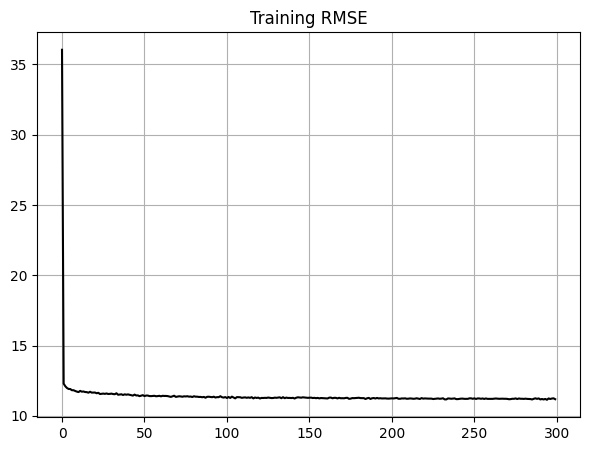

In [121]:
# Plot RMSE Loss over epochs
plt.figure(figsize=(7,5))
plt.plot(np.sqrt(history.history['loss']), color="black")
plt.title("Training RMSE")
plt.grid(True)
plt.show()

## Generating Predictions on Train and Test Sets


In [ ]:
# Predict on test data
testPredict = model.predict(testX)
print(f"Test predictions shape: {testPredict.shape}")

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
Test predictions shape: (104, 7)


In [ ]:
# Evaluate predictions for each horizon day 
for h in range(horizon):
    y_true = testY[:, h]
    y_pred = testPredict[:, h]
    
    mae = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    
    print(f"Day {h+1} ahead - MAE: {mae:.4f}, RMSE: {rmse:.4f}")

Day 1 ahead - MAE: 5.9101, RMSE: 7.6204
Day 2 ahead - MAE: 6.5467, RMSE: 8.6191
Day 3 ahead - MAE: 7.0387, RMSE: 9.1070
Day 4 ahead - MAE: 7.4222, RMSE: 9.3163
Day 5 ahead - MAE: 7.3757, RMSE: 9.4292
Day 6 ahead - MAE: 7.5988, RMSE: 9.5813
Day 7 ahead - MAE: 8.4509, RMSE: 10.1073


In [ ]:
# Overall evaluation across all horizon days
overall_mae = mean_absolute_error(testY.flatten(), testPredict.flatten())
overall_rmse = np.sqrt(mean_squared_error(testY.flatten(), testPredict.flatten()))
print(f"\nOverall - MAE: {overall_mae:.4f}, RMSE: {overall_rmse:.4f}")


Overall - MAE: 7.1919, RMSE: 9.1414


## Test-Set Comparison (Actual vs Predicted)
When plotting actual vs predicted humidity on the test set only, the two lines remain close and parallel, showing good alignment.
Key observations:

- Peaks and dips are captured ocationally.

- The day-to-day fluctuations are followed with reasonable accuracy.

- No noticeable systematic drift is observed across the prediction horizon.

This agrees with the moderate but stable RMSE seen during training.

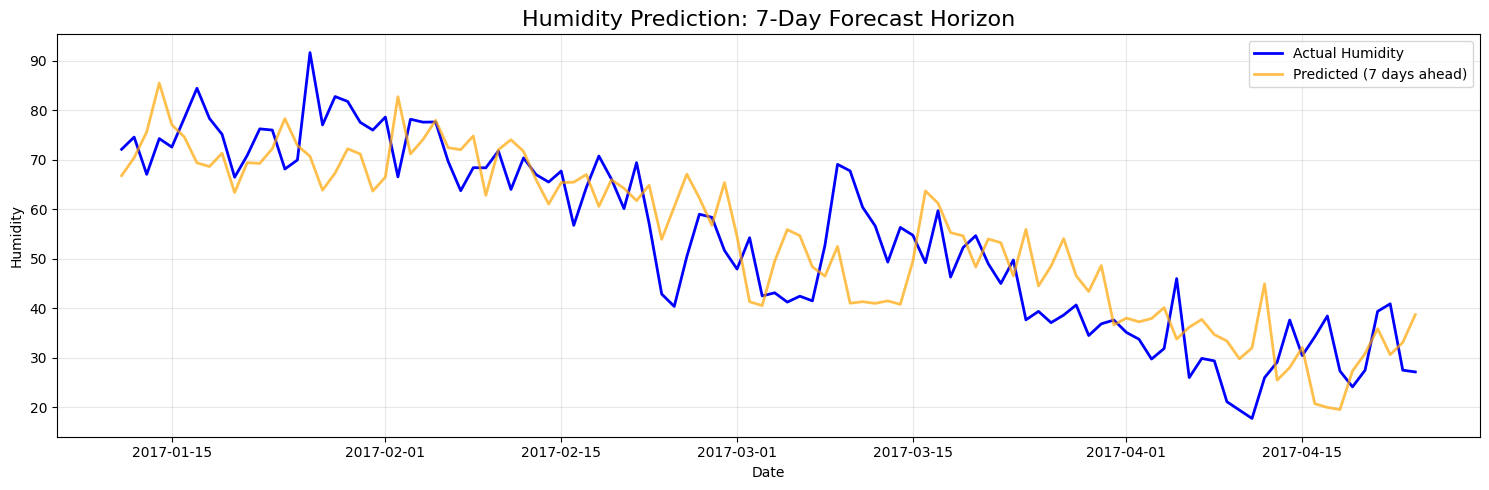

In [ ]:
# First day of each 7-day forecast
first_step_predictions = testPredict[:, 0] 

# Plot actual vs predicted
plot_start_idx = step + horizon - 1
test_subset = test[plot_start_idx:plot_start_idx+len(first_step_predictions)]
test_dates_subset = test_df.index[plot_start_idx:plot_start_idx+len(first_step_predictions)]

plt.figure(figsize=(15, 5))
plt.plot(test_dates_subset, test_subset, label="Actual Humidity", color='blue', linewidth=2)
plt.plot(test_dates_subset, first_step_predictions, label=f"Predicted ({horizon} days ahead)", 
         color='orange', alpha=0.7, linewidth=2)
plt.title(f"Humidity Prediction: {horizon}-Day Forecast Horizon", fontsize=16)
plt.xlabel("Date")
plt.ylabel("Humidity")
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# Residuals

## The histogram of residuals is approximately centered around zero, showing:

- A symmetric distribution

- No heavy skew

- No problematic long tail on one side

This pattern suggests that prediction errors are mostly random rather than systematic.

The spread of residuals is consistent with the RMSE value of ~9.14.


## Plotting the residuals chronologically shows:

- Fluctuations around zero

- No clear temporal trend

- Occasional spikes representing isolated prediction errors

- No evidence of model drift or structural break

This confirms that the RNN’s performance remains stable across the entire test period.

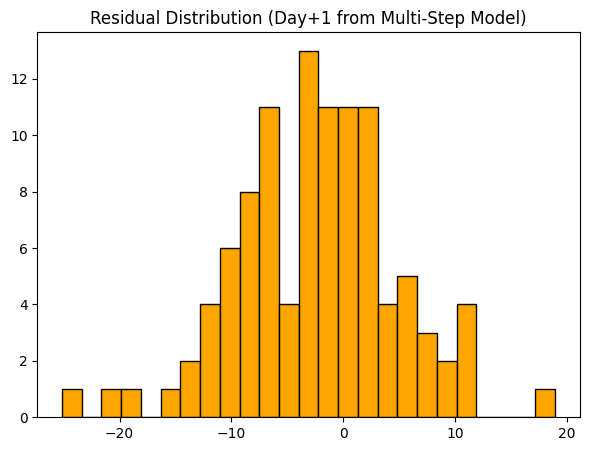

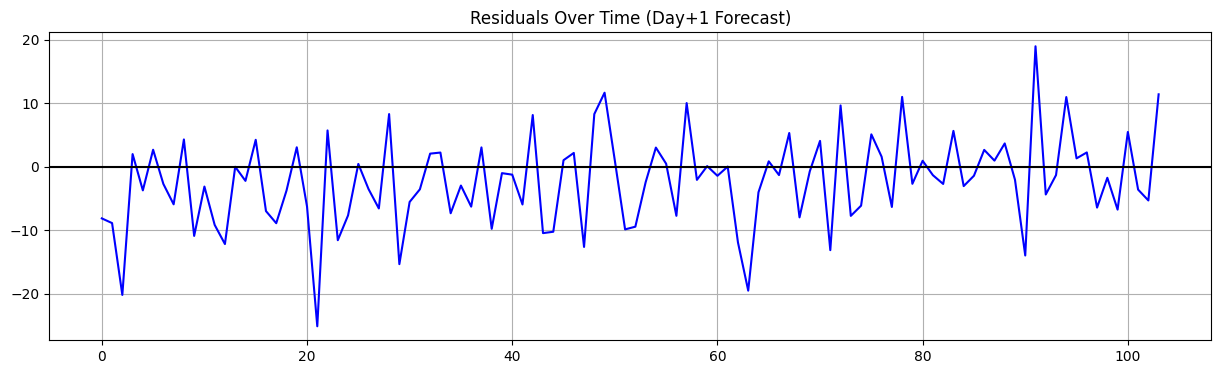

In [127]:
residuals = testPredict[:,0] - testY[:,0]

plt.figure(figsize=(7,5))
plt.hist(residuals, bins=25, edgecolor='k', color='orange')
plt.title("Residual Distribution (Day+1 from Multi-Step Model)")
plt.show()

plt.figure(figsize=(15,4))
plt.plot(residuals, c='blue')
plt.axhline(0, color='black')
plt.grid(True)
plt.title("Residuals Over Time (Day+1 Forecast)")
plt.show()